In [1]:
from transformers import Trainer,get_linear_schedule_with_warmup,RobertaTokenizer,BertForSequenceClassification,BitsAndBytesConfig
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm
import psutil
from sklearn.model_selection import train_test_split
from peft import prepare_model_for_kbit_training
from peft import get_peft_model
import time
from collections import defaultdict
import math

In [2]:
def print_trainable_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:,}")
    print(f"Total parameters: {total:,}")
    print(f"Percentage of trainable params: {100 * trainable / total:.2f}%")

## Custom RoBERTa class needs work

In [3]:
from transformers import RobertaForSequenceClassification
import torch.nn as nn

class RobertaForSequenceClassificationWithCustomHead(RobertaForSequenceClassification):
    def __init__(self, config):
        super().__init__(config)
        self.custom_layer = nn.Sequential(
            nn.Linear(config.num_labels, 64),
            nn.ReLU(),
            nn.Linear(64, config.num_labels)
        )

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        accepted_keys = {
            "input_ids", "attention_mask", "labels", "token_type_ids",
            "position_ids", "head_mask", "inputs_embeds", "output_attentions",
            "output_hidden_states", "return_dict"
        }
        filtered_kwargs = {k: v for k, v in kwargs.items() if k in accepted_keys}

        outputs = super().forward(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
            **filtered_kwargs
        )

        logits = outputs.logits

        # Move custom layer to correct device if needed
        if next(self.custom_layer.parameters()).device != logits.device:
            self.custom_layer.to(logits.device)

        custom_logits = self.custom_layer(logits)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(custom_logits, labels)

        return type(outputs)(
            loss=loss,
            logits=custom_logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


In [4]:
from transformers import RobertaTokenizerFast
from transformers import RobertaForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Number of available GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU available.")
device
model = RobertaForSequenceClassificationWithCustomHead.from_pretrained("roberta-base", num_labels=15, device_map="auto")
print(model.config)
print_trainable_parameters(model)

# Pretrained RoBERTa tokenizer (e.g. roberta-base)
pretrained_tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

# Your custom tokenizer trained on OOL tokens
custom_tokenizer = RobertaTokenizerFast.from_pretrained('./tokenizer') # Try to remove Fast?

Number of available GPUs: 1
GPU Name: NVIDIA GeForce RTX 3080


HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 2s [Retry 2/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 4s [Retry 3/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 8s [Retry 4/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 8s [Retry 5/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/conf

RobertaConfig {
  "architectures": [
    "RobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5",
    "6": "LABEL_6",
    "7": "LABEL_7",
    "8": "LABEL_8",
    "9": "LABEL_9",
    "10": "LABEL_10",
    "11": "LABEL_11",
    "12": "LABEL_12",
    "13": "LABEL_13",
    "14": "LABEL_14"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_10": 10,
    "LABEL_11": 11,
    "LABEL_12": 12,
    "LABEL_13": 13,
    "LABEL_14": 14,
    "LABEL_2": 2,
    "LABEL_3": 3,
    "LABEL_4": 4,
    "LABEL_5": 5,
    "LABEL_6": 6,
    "LABEL_7": 7,
    "LABEL_8": 8,
    "LABEL_9": 9
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 51

HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 2s [Retry 2/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 4s [Retry 3/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 8s [Retry 4/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json
Retrying in 8s [Retry 5/5].
HTTP Error 429 thrown while requesting HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json


In [5]:
pretrained_vocab = set(pretrained_tokenizer.get_vocab().keys())
custom_vocab = set(custom_tokenizer.get_vocab().keys())

# Identify tokens present in custom but not in pretrained
new_tokens = list(custom_vocab - pretrained_vocab)

print(f"Found {len(new_tokens)} new tokens to add.")

Found 28604 new tokens to add.


In [6]:
# Add new tokens to the pretrained tokenizer
num_added = pretrained_tokenizer.add_tokens(new_tokens)
print(f"Successfully added {num_added} new tokens.")

Successfully added 28604 new tokens.


In [7]:
model.resize_token_embeddings(len(pretrained_tokenizer))

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(78869, 768, padding_idx=1)

In [8]:
from peft import get_peft_model, LoraConfig, TaskType

config = LoraConfig(
    task_type=TaskType.SEQ_CLS,     # or SEQ_2_SEQ_LM, TOKEN_CLS, etc.
    r=8,
    lora_alpha=32,
    lora_dropout=0.2,
    target_modules=["query", "key", "value"],  # Adjust for RoBERTa
    use_dora=True
)

model = get_peft_model(model, config)
print_trainable_parameters(model)
#model.to(device)

Trainable parameters: 1,072,143
Total parameters: 147,699,181
Percentage of trainable params: 0.73%


In [9]:
from datasets import load_dataset
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

data = pd.read_pickle('./saved_data/encoded_data.pck')
le = LabelEncoder()
data['target'] = le.fit_transform(data['Attack_type'])

data2 = pd.read_csv(".\data\Edge-IIoTset dataset\Selected dataset for ML and DL\ML-EdgeIIoT-dataset.csv")
columns = list(data2.columns[:-2])

In [10]:
with open("prompt_column_name_encoded_data.txt","w") as f:
    for _, row in data.iterrows():
        tokens = row['encoded_PPFLE'].split(" ")
        formatted = []
        for idx, (col, tok) in enumerate(zip(columns, tokens)):
            end_char = "." if idx == len(tokens) - 1 else ";"
            formatted.append(f"{col}: {tok}{end_char}")
        row_string = " ".join(formatted)
        f.write(f"You are an expert in network traffic classification. Based on the provided network traffic attributes, you must determine whether the traffic is " +
                f"'Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP', 'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning', 'Ransomware', 'SQL_injection', 'Uploading', " + 
                f"'Vulnerability_scanner', or 'XSS'. Here are the encoded attributes, '{row_string}'." + "\n")
#'<s>','<pad>','</s>','<unk>','<mask>'

In [11]:
with open("prompt_column_name_encoded_data.txt", "r") as f:
    prompt_lines = f.readlines()

# Strip newline characters
prompt_lines = [prompt_line.strip() for prompt_line in prompt_lines]
prompt_data = {
    "encoded_PPFLE_prompt": prompt_lines, 'Attack_type': data['Attack_type'], 'Attack_label': data['Attack_label'], 'target': data['target']
}
prompt_df = pd.DataFrame(prompt_data)
prompt_df.sample(15)

,encoded_PPFLE_prompt,Attack_type,Attack_label,target
108159,You are an expert in network traffic classific...,Normal,0,7
70782,You are an expert in network traffic classific...,Port_Scanning,1,9
151908,You are an expert in network traffic classific...,DDoS_ICMP,1,2
141663,You are an expert in network traffic classific...,DDoS_UDP,1,4
42314,You are an expert in network traffic classific...,DDoS_HTTP,1,1
31309,You are an expert in network traffic classific...,SQL_injection,1,11
29942,You are an expert in network traffic classific...,SQL_injection,1,11
117352,You are an expert in network traffic classific...,Normal,0,7
53353,You are an expert in network traffic classific...,DDoS_TCP,1,3
156020,You are an expert in network traffic classific...,DDoS_ICMP,1,2


In [12]:
train_set = prompt_df.sample(frac=0.7,random_state=42).reset_index(drop=True)

remaining = prompt_df.drop(train_set.index).reset_index(drop=True)

test_set = remaining.sample(frac=0.5,random_state=42).reset_index(drop=True)

val_set = remaining.drop(test_set.index).reset_index(drop=True)

print(train_set.shape,val_set.shape,test_set.shape)

(110460, 4) (23670, 4) (23670, 4)


In [13]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

train_set, test_set = train_test_split(prompt_df, test_size=test_ratio,stratify=prompt_df.iloc[:,-1], random_state=42)
train_set, val_set = train_test_split(train_set, test_size=val_ratio/(val_ratio+train_ratio),stratify=train_set.iloc[:,-1], random_state=42)

In [14]:
train_set.shape,val_set.shape,test_set.shape

((110460, 4), (23670, 4), (23670, 4))

In [15]:
TARGET_LIST = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
                'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
                'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
                'XSS']

In [16]:
prompt_df[prompt_df['Attack_type']=='Uploading'].head(5)

,encoded_PPFLE_prompt,Attack_type,Attack_label,target
13140,You are an expert in network traffic classific...,Uploading,1,12
13141,You are an expert in network traffic classific...,Uploading,1,12
13142,You are an expert in network traffic classific...,Uploading,1,12
13143,You are an expert in network traffic classific...,Uploading,1,12
13144,You are an expert in network traffic classific...,Uploading,1,12


class CustomDataset(Dataset):
  def __init__(self,encodings,df,max_len):
    self.encodings = encodings
    self.df = df
    self.max_len=max_len
    self.targets = self.df['target'].tolist()

  def __len__(self):
    return len(self.df)

  def __getitem__(self,idx):
    target = self.targets[idx]
    encoding = self.encodings[idx]

    return {
        'input_ids':encoding['input_ids'].flatten(),
        'attention_mask':encoding['attention_mask'].flatten(),
        'targets':torch.tensor(target,dtype=torch.long)
    }

In [17]:
from datasets import load_dataset, Dataset
from transformers import RobertaTokenizerFast
import torch

# Define tokenization function
def tokenize_function(row):
    return pretrained_tokenizer(
        row["encoded_PPFLE_prompt"],               # replace with your actual column
        padding="max_length",
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )

# Tokenize entire dataset
train_set_enc = (Dataset.from_pandas(train_set)).map(tokenize_function, batched=True)
val_set_enc = (Dataset.from_pandas(val_set)).map(tokenize_function, batched=True)
test_set_enc = (Dataset.from_pandas(test_set)).map(tokenize_function, batched=True)

# Save to disk (recommended)
train_set_enc.save_to_disk('dora_prompt_column_name_roberta_train_encodings.pt')
val_set_enc.save_to_disk('dora_prompt_column_name_roberta_val_encodings.pt')
test_set_enc.save_to_disk('dora_prompt_column_name_roberta_test_encodings.pt')

Map:   0%|          | 0/110460 [00:00<?, ? examples/s]

Map:   0%|          | 0/23670 [00:00<?, ? examples/s]

Map:   0%|          | 0/23670 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/110460 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23670 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/23670 [00:00<?, ? examples/s]

In [18]:
from datasets import load_dataset, Dataset
from datasets import load_from_disk

train_set_enc = load_from_disk('dora_prompt_column_name_roberta_train_encodings.pt')
print(len(train_set_enc))
val_set_enc = load_from_disk('dora_prompt_column_name_roberta_val_encodings.pt')
print(len(val_set_enc))
test_set_enc = load_from_disk('dora_prompt_column_name_roberta_test_encodings.pt')
print(len(test_set_enc))

110460
23670
23670


In [19]:
def set_dataset_format(dataset):
    dataset = dataset.rename_column('target', "labels")
    dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]  # include "labels" column
    )
    return dataset

train_dataset = set_dataset_format(train_set_enc)
val_dataset = set_dataset_format(val_set_enc)
test_dataset = set_dataset_format(test_set_enc)

In [20]:
MAX_LEN=512
BATCH_SIZE=32

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0

)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0

)

test_data = next(iter(train_loader))

print(test_data['input_ids'].shape)

labels = train_dataset["labels"]
print(f"Labels min, max: {labels.min(), labels.max()}")
print(f"Labels dtype: {labels.dtype}")

for batch in train_loader:
    print(f"batch.keys = {batch.keys()}, ")
    break

print(train_dataset['input_ids'][0])

torch.Size([32, 512])
Labels min, max: (tensor(0), tensor(14))
Labels dtype: torch.int64
batch.keys = dict_keys(['labels', 'input_ids', 'attention_mask']), 
tensor([    0,  1185,    32,    41,  3827,    11,  1546,  1703, 20257,     4,
         7253,    15,     5,  1286,  1546,  1703, 16763,     6,    47,   531,
         3094,   549,     5,  1703,    16,   128, 19085, 11219,  3934,   128,
          495, 41501,  1215, 49244,  3934,   128,   495, 41501,  1215,  2371,
         7629,  3934,   128,   495, 41501,  1215,  6078,   510,  3934,   128,
          495, 41501,  1215,   791,  5174,  3934,   128,   597,  6082, 17265,
          154,  3934,   128, 36548,   448,  3934,   128, 45647,  3934,   128,
        44917,  3934,   128, 22117,  1215, 42450,  3509,  3934,   128,   500,
        32387, 10680,  3934,   128, 46608,  1215,   179, 35892,  3934,   128,
        48800,   154,  3934,   128,   846, 45706,  1215, 43511,  1396,  3934,
           50,   128,  1000,  8108,  2652,  1398,    32,     5,

In [21]:
def load_chkpt(model,version):
  return model.load_state_dict(torch.load(f"./saved_model/securityRoBERTa{version}.0.pt"))

In [22]:
from transformers import TrainerCallback
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.epoch_train_losses = []
        self.epoch_train_accuracies = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        
        if "loss" in logs:
            self.epoch_train_losses.append(logs["loss"])

        if "eval_accuracy" in logs:
            self.epoch_train_accuracies.append(logs["eval_accuracy"])

In [23]:
from transformers import Trainer
import torch
import numpy as np

class CustomTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.history = defaultdict(list)
        self.best_val_acc = 0.0

    def evaluate_and_save(self, epoch, model_version):
        # Evaluate on validation set
        metrics = self.evaluate()
        print(metrics.keys())
        val_acc = metrics["eval_accuracy"]
        val_loss = metrics["eval_loss"]
        self.history["val_acc"].append(val_acc)
        self.history["val_loss"].append(val_loss)

        # Save best model
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc
            self.save_model(f"./saved_model/{model_version}{epoch+1}.0.pt")
            print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

    def log_training_epoch(self, train_loss, train_acc):
        self.history["train_loss"].append(train_loss)
        self.history["train_acc"].append(train_acc)

In [24]:
EPOCHS=3

In [25]:
optimizer_dora = torch.optim.AdamW(model.parameters(),lr=1e-5)
total_steps = len(train_loader)*EPOCHS

scheduler_dora = get_linear_schedule_with_warmup(
    optimizer_dora,
    num_warmup_steps= 0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss()

In [26]:
from transformers import TrainingArguments

batch_size = 32
gradient_accumulation_steps = 4

# output dir 
model_version = "securityRoBERTa_BasePromptColumnNameDoRA_"
model_dir = f"{model_version}"

training_args = TrainingArguments(
    run_name=model_version,
    output_dir=model_dir,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    num_train_epochs=1,
    lr_scheduler_type="constant",
    logging_dir=f"{model_dir}/logs",
    fp16=True,  # Enable mixed precision training
    dataloader_num_workers=4,  # Adjust based on your CPU capabilities
    gradient_checkpointing=True,  # Enable gradient checkpointing to save memory
    report_to="none",  # Disable reporting to avoid unnecessary overhead
    label_names=["labels"],
)

In [27]:
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix
# The parameters after appling DoRA
print_trainable_parameters(model)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "macro_f1": macro_f1}

# model.to(device)

Trainable parameters: 1,072,143
Total parameters: 147,699,181
Percentage of trainable params: 0.73%


In [28]:
import json

In [29]:
from collections import defaultdict
import time

metrics_callback = MetricsCallback()

# New trainer
trainer_dora = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=pretrained_tokenizer,
    callbacks=[metrics_callback]
)

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    
    # Train for one epoch (Trainer handles batches internally)
    trainer_dora.train()

    trainer_dora.log_training_epoch(metrics_callback.epoch_train_losses[-1], metrics_callback.epoch_train_accuracies[-1])

    # Evaluate and potentially save best model
    trainer_dora.evaluate_and_save(
        epoch,
        model_version
    )

history_roberta_base_dora = trainer_dora.history

# Save full history and training time
end_time = time.time()
history_roberta_base_dora["training_time"].append(end_time - start_time)

torch.save(history_roberta_base_dora, "./saved_model/history_roberta_base_dora_prompt_column_name.pt")
print("Training complete and history saved.")



Epoch 1/3


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,10.817100,2.690380,0.089269,0.010927


dict_keys(['eval_loss', 'eval_accuracy', 'eval_macro_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'epoch'])
Saved best model at epoch 1 with val_acc=0.0893

Epoch 2/3


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,10.737500,2.674034,0.089269,0.010927


dict_keys(['eval_loss', 'eval_accuracy', 'eval_macro_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'epoch'])

Epoch 3/3


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,10.679800,2.662812,0.089269,0.010927


dict_keys(['eval_loss', 'eval_accuracy', 'eval_macro_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'epoch'])
Training complete and history saved.


In [30]:
# Load
history_roberta_base_dora = torch.load("./saved_model/history_roberta_base_dora_prompt_column_name.pt", weights_only=False)

# Still a defaultdict with tensors
print(type(history_roberta_base_dora))  # defaultdict
print(type(history_roberta_base_dora['train_acc'][0]))  # torch.Tensor

<class 'collections.defaultdict'>
<class 'float'>


[10.8171, 10.7375, 10.6798]


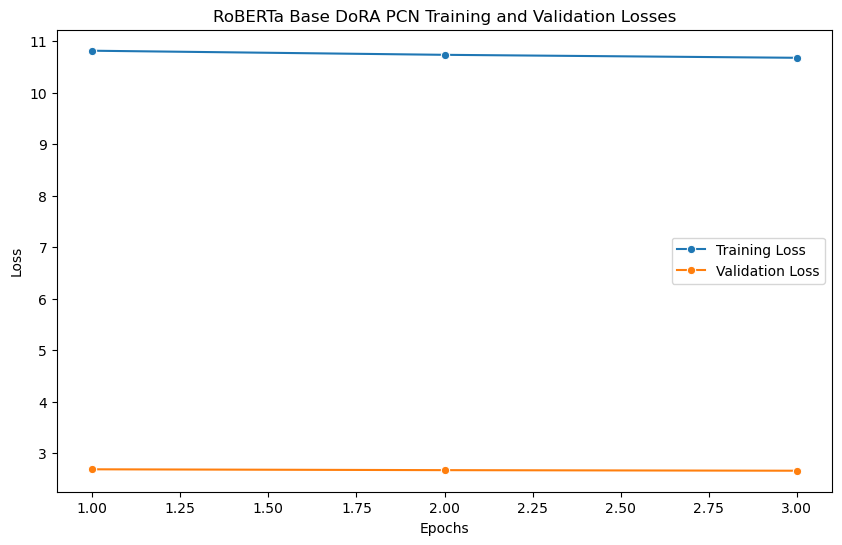

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

epochs = range(1, EPOCHS+1)
train_losses = history_roberta_base_dora['train_loss']
print(train_losses)
val_losses = history_roberta_base_dora['val_loss']

plt.figure(figsize=(10, 6))

sns.lineplot(x=epochs, y=train_losses, label='Training Loss',marker="o")
sns.lineplot(x=epochs, y=val_losses, label='Validation Loss',marker="o")

plt.title('RoBERTa Base DoRA PCN Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('./roberta-base-dora-prompt-column-name-training-validation-losses.png',dpi=780)
plt.show()

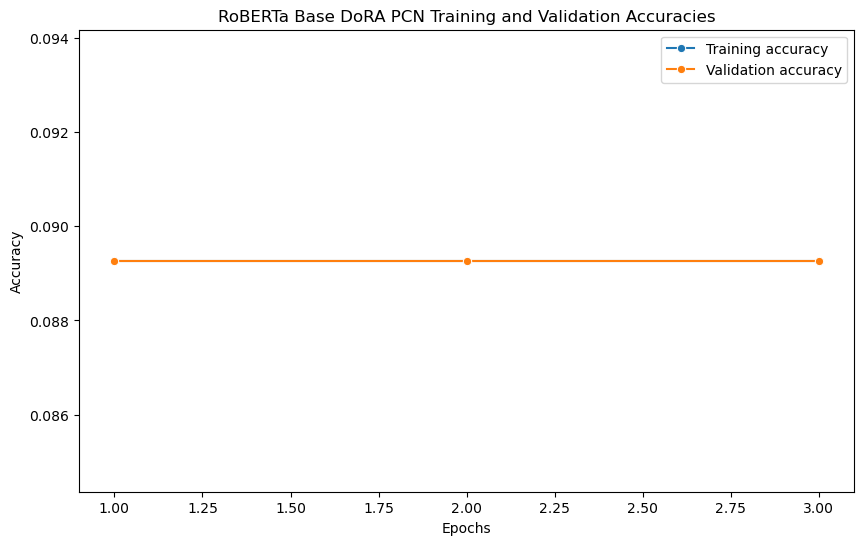

In [32]:
epochs = range(1, EPOCHS+1)
train_accuracies = history_roberta_base_dora['train_acc']
val_accuracies = history_roberta_base_dora['val_acc']

plt.figure(figsize=(10, 6))

sns.lineplot(x=epochs, y=train_accuracies, label='Training accuracy',marker='o')
sns.lineplot(x=epochs, y=val_accuracies, label='Validation accuracy',marker='o')

plt.title('RoBERTa Base DoRA PCN Training and Validation Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('./roberta-base-dora-prompt-column-name-training-validation-accuracies.png',dpi=780)
plt.show()

In [33]:
from transformers.trainer_utils import PredictionOutput
from sklearn.metrics import confusion_matrix,classification_report

def get_predictions(trainer, test_dataset):
    # Runs prediction
    output: PredictionOutput = trainer.predict(test_dataset)

    # Get raw logits and labels
    logits = torch.tensor(output.predictions)
    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    labels = torch.tensor(output.label_ids)

    return preds, probs, labels

In [34]:
preds, probs, labels = get_predictions(trainer_dora, test_dataset)

In [35]:
torch.save(preds,"./saved_model/roberta_base_dora_prompt_column_name_predictions.pt")
torch.save(probs,"./saved_model/roberta_base_dora_prompt_column_name_predictions_probs.pt")
torch.save(labels,"./saved_model/roberta_base_dora_prompt_column_name_real_values.pt") 

In [36]:
target_names = ['Backdoor', 'DDoS_HTTP', 'DDoS_ICMP', 'DDoS_TCP', 'DDoS_UDP',
       'Fingerprinting', 'MITM', 'Normal', 'Password', 'Port_Scanning',
       'Ransomware', 'SQL_injection', 'Uploading', 'Vulnerability_scanner',
       'XSS']

In [37]:
s = set()

In [38]:
for elt in preds:
  s.add(elt.item())

In [39]:
actual_considered_classes = [TARGET_LIST[i] for i in s]
actual_considered_classes

['DDoS_ICMP']

In [40]:
data['Attack_type'].value_counts()

Attack_type
Normal                   24301
DDoS_UDP                 14498
DDoS_ICMP                14090
Ransomware               10925
DDoS_HTTP                10561
SQL_injection            10311
Uploading                10269
DDoS_TCP                 10247
Backdoor                 10195
Vulnerability_scanner    10076
Port_Scanning            10071
XSS                      10052
Password                  9989
MITM                      1214
Fingerprinting            1001
Name: count, dtype: int64

In [41]:
def show_confusion_matrix(confusion_matrix):

    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d')
    plt.xticks(rotation=90)
    plt.title("RoBERTa Base DoRA PCN Confusion Matrix")
    plt.ylabel('Real threats')
    plt.xlabel('Predicted threats')
    plt.savefig('./roberta-base-dora-prompt-column-name-confusion-matrix.png',dpi=780)
    plt.show()

In [42]:
print(classification_report(labels,preds,target_names=TARGET_LIST))

                       precision    recall  f1-score   support

             Backdoor       0.00      0.00      0.00      1529
            DDoS_HTTP       0.00      0.00      0.00      1584
            DDoS_ICMP       0.09      1.00      0.16      2114
             DDoS_TCP       0.00      0.00      0.00      1537
             DDoS_UDP       0.00      0.00      0.00      2175
       Fingerprinting       0.00      0.00      0.00       150
                 MITM       0.00      0.00      0.00       182
               Normal       0.00      0.00      0.00      3645
             Password       0.00      0.00      0.00      1498
        Port_Scanning       0.00      0.00      0.00      1511
           Ransomware       0.00      0.00      0.00      1639
        SQL_injection       0.00      0.00      0.00      1547
            Uploading       0.00      0.00      0.00      1540
Vulnerability_scanner       0.00      0.00      0.00      1511
                  XSS       0.00      0.00      0.00  

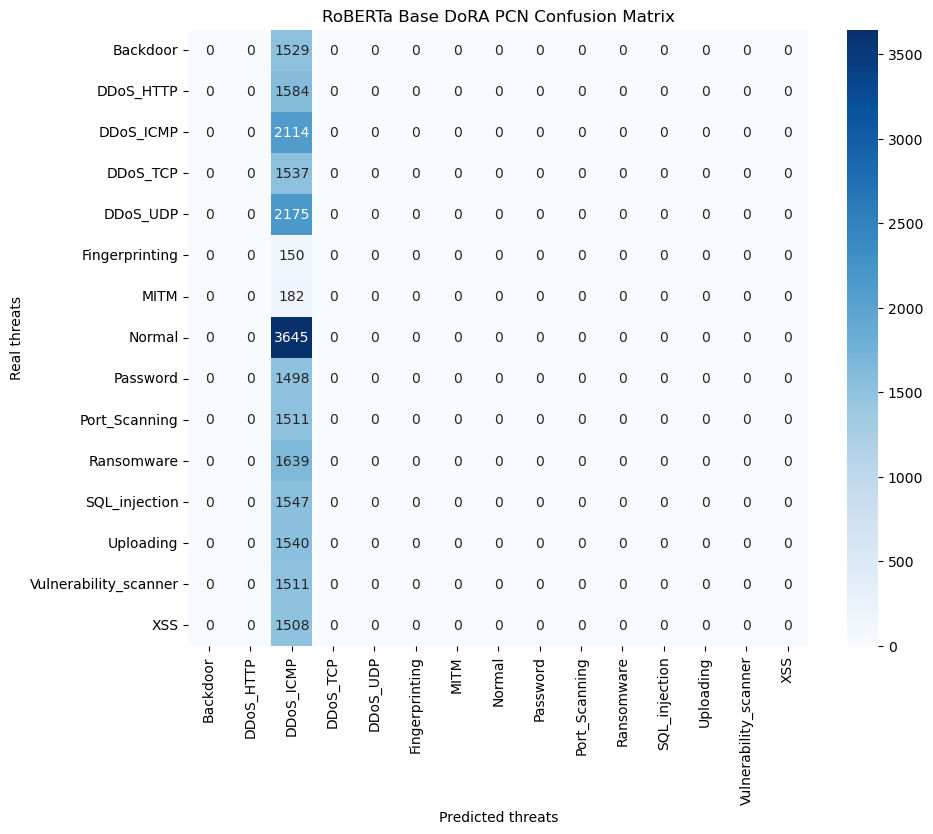

In [43]:
cm = confusion_matrix(labels,preds)
df_cm = pd.DataFrame(cm,index=TARGET_LIST,columns=TARGET_LIST)
show_confusion_matrix(df_cm)

In [44]:
y_true = labels.cpu().numpy()
y_score = preds.cpu().numpy()